<a href="https://colab.research.google.com/github/vivekkumbhar1209/vivekkumbhar2/blob/main/Research_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import seaborn as sns

In [3]:

import pandas as pd

# Load the CSV file to inspect its contents
file_path = '/content/Responce file.csv'
data = pd.read_csv(file_path)

In [4]:
data.head()

,Timestamp,Full Name,Email,Mobile Number,Age Group,Gender,Location,Martial Status,Occupation,Simcard Company,Tenure with Company,Current Service Used,Preferred Payment Method,satisfication with Services,Resaons For Choose Current Service,Likelihood to Recommend,Comments and Feedback,Consent to Participate
0,8/23/2024 15:34:21,Omkar Keshav Shitole,omkarkshitole@gmail.com,8975295673,18-24,Male,Pune,NaN,Student,NaN,Less than 1 Year,Internet,Mobile Payment,4,Service Quality,3,NaN,I consent to the collection and use of my dat...
1,8/25/2024 17:21:06,omkar Shitole,omkarkshitole@gmail.com,8975295673,18-24,Male,pune,Single,Student,NaN,1-2 Years,Mobile,Credit Card,5,Price,5,NaN,I consent to the collection and use of my dat...
2,8/25/2024 20:01:42,Savkar Bhagyashree Dinkar,bsavkar123@gmail.com,8177875913,18-24,Female,Pune,Single,Student,Airtel,3-5 Years,"Mobile, Internet",Mobile Payment,4,Service Quality,3,NaN,I consent to the collection and use of my dat...
3,8/26/2024 20:59:42,Sohel patel,sohelpatel8860@gmail.com,07666069428,18-24,Male,Pune,Single,Student,Airtel,More Than 5 Years,"Mobile, Internet, TV",Mobile Payment,4,Service Quality,5,NaN,I consent to the collection and use of my dat...
4,8/26/2024 21:01:50,Sohel P,sohelpatel4886@gmail.com,07666069428,18-24,Male,"Pimpri,Pune",Single,Student,Airtel,More Than 5 Years,"Mobile, Internet, TV",Mobile Payment,5,Service Quality,5,"Best And Great Experience while Streaming, No ...",I consent to the collection and use of my dat...


In [5]:
# Step 1: Remove duplicate rows
data_cleaned = data.drop_duplicates()

# Step 2: Standardize text data (lowercase and strip leading/trailing spaces in 'Location')
data_cleaned['Location'] = data_cleaned['Location'].str.lower().str.strip()

# Step 3: Handle missing values
# For now, we'll fill missing values in 'Simcard Company' and 'Comments and Feedback' with a placeholder 'Unknown'
data_cleaned['Simcard Company'].fillna('Unknown', inplace=True)
data_cleaned['Comments and Feedback'].fillna('No Feedback', inplace=True)

# Step 4: Correct formatting of 'Mobile Number' (removing spaces or special characters)
data_cleaned['Mobile Number'] = data_cleaned['Mobile Number'].astype(str).str.replace(r'\D', '', regex=True)

# Step 5: Convert categorical data to numeric using one-hot encoding for Gender, Simcard Company, etc.
data_encoded = pd.get_dummies(data_cleaned, columns=['Gender', 'Simcard Company', 'Preferred  Payment Method'])

# Step 6: Check the column names before dropping
print(data_encoded.columns)  # This will list all the columns

# Now drop the relevant columns that exist
columns_to_drop = ['Full Name', 'Email', 'Comments and Feedback', 'Consent to Participate']
data_final = data_encoded.drop(columns=[col for col in columns_to_drop if col in data_encoded.columns])

# Display the cleaned and encoded data
data_final.head()


Index(['Timestamp', 'Full Name ', 'Email ', 'Mobile Number', 'Age Group',
       'Location', 'Martial Status', 'Occupation', 'Tenure with Company',
       'Current Service Used', 'satisfication with Services',
       'Resaons For Choose Current Service', 'Likelihood to Recommend',
       'Comments and Feedback', 'Consent  to Participate', 'Gender_Female',
       'Gender_Hi jada', 'Gender_Male', 'Gender_Male, Female',
       'Gender_Transgender', 'Simcard Company_Airtel',
       'Simcard Company_Airtel, BSNL', 'Simcard Company_Airtel, VI',
       'Simcard Company_Apni Khud ki company hai', 'Simcard Company_BSNL',
       'Simcard Company_BSNL, VI', 'Simcard Company_Jio',
       'Simcard Company_Jio, Airtel', 'Simcard Company_Jio, Airtel, BSNL',
       'Simcard Company_Jio, Airtel, VI', 'Simcard Company_Jio, BSNL',
       'Simcard Company_Jio, VI', 'Simcard Company_Proporion',
       'Simcard Company_Unknown', 'Simcard Company_VI', 'Simcard Company_idea',
       'Preferred  Payment Method

<ipython-input-5-2e83ab7c8cb8>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned['Simcard Company'].fillna('Unknown', inplace=True)
<ipython-input-5-2e83ab7c8cb8>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

,Timestamp,Full Name,Email,Mobile Number,Age Group,Location,Martial Status,Occupation,Tenure with Company,Current Service Used,...,Simcard Company_Unknown,Simcard Company_VI,Simcard Company_idea,Preferred Payment Method_Bank Transfer,Preferred Payment Method_Cash,Preferred Payment Method_Cheque,Preferred Payment Method_Credit Card,Preferred Payment Method_Fuakt,Preferred Payment Method_Mobile Payment,Preferred Payment Method_Sometime Cash Sometime UPI
0,8/23/2024 15:34:21,Omkar Keshav Shitole,omkarkshitole@gmail.com,8975295673,18-24,pune,NaN,Student,Less than 1 Year,Internet,...,True,False,False,False,False,False,False,False,True,False
1,8/25/2024 17:21:06,omkar Shitole,omkarkshitole@gmail.com,8975295673,18-24,pune,Single,Student,1-2 Years,Mobile,...,True,False,False,False,False,False,True,False,False,False
2,8/25/2024 20:01:42,Savkar Bhagyashree Dinkar,bsavkar123@gmail.com,8177875913,18-24,pune,Single,Student,3-5 Years,"Mobile, Internet",...,False,False,False,False,False,False,False,False,True,False
3,8/26/2024 20:59:42,Sohel patel,sohelpatel8860@gmail.com,07666069428,18-24,pune,Single,Student,More Than 5 Years,"Mobile, Internet, TV",...,False,False,False,False,False,False,False,False,True,False
4,8/26/2024 21:01:50,Sohel P,sohelpatel4886@gmail.com,07666069428,18-24,"pimpri,pune",Single,Student,More Than 5 Years,"Mobile, Internet, TV",...,False,False,False,False,False,False,False,False,True,False


In [7]:
import pandas as pd

# Load the CSV file
file_path = r'/content/Responce file.csv'

data = pd.read_csv(file_path)

# Display the column names using the correct variable
print(data.columns)

Index(['Timestamp', 'Full Name ', 'Email ', 'Mobile Number', 'Age Group',
       'Gender', 'Location', 'Martial Status', 'Occupation', 'Simcard Company',
       'Tenure with Company', 'Current Service Used',
       'Preferred  Payment Method', 'satisfication with Services',
       'Resaons For Choose Current Service', 'Likelihood to Recommend',
       'Comments and Feedback', 'Consent  to Participate'],
      dtype='object')


In [8]:
#Encode categorical variables (LabelEncoding / OneHot).

In [10]:
import pandas as pd

# Load the uploaded CSV file
file_path = "/content/Responce file.csv"
df = pd.read_csv(file_path)

# Display the first few rows and data types to identify categorical columns
df.head(), df.dtypes


(            Timestamp                 Full Name                     Email   \
 0  8/23/2024 15:34:21      Omkar Keshav Shitole    omkarkshitole@gmail.com   
 1  8/25/2024 17:21:06              omkar Shitole   omkarkshitole@gmail.com   
 2  8/25/2024 20:01:42  Savkar Bhagyashree Dinkar      bsavkar123@gmail.com   
 3  8/26/2024 20:59:42                Sohel patel  sohelpatel8860@gmail.com   
 4  8/26/2024 21:01:50                    Sohel P  sohelpatel4886@gmail.com   
 
   Mobile Number Age Group  Gender     Location Martial Status Occupation  \
 0    8975295673     18-24    Male         Pune            NaN   Student    
 1    8975295673     18-24    Male         pune         Single   Student    
 2    8177875913     18-24  Female         Pune         Single   Student    
 3   07666069428     18-24    Male        Pune          Single   Student    
 4   07666069428     18-24    Male  Pimpri,Pune         Single    Student   
 
   Simcard Company Tenure with Company  Current Service Used

In [16]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Strip whitespace from column names
df.columns = df.columns.str.strip()

# Step 2: Drop irrelevant columns
df_cleaned = df.drop(columns=[
    'Timestamp', 'Full Name', 'Email', 'Mobile Number',
    'Comments and Feedback', 'Consent  to Participate'
])

# Step 3: Identify categorical columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

# Step 4: Label Encoding for binary/ordinal categorical columns
label_encoded_cols = ['Gender', 'Martial Status', 'Simcard Company']
label_enc = LabelEncoder()

for col in label_encoded_cols:
    df_cleaned[col] = label_enc.fit_transform(df_cleaned[col].astype(str))

# Step 5: One-Hot Encoding for remaining object columns
remaining_cats = [col for col in categorical_cols if col not in label_encoded_cols]
df_encoded = pd.get_dummies(df_cleaned, columns=remaining_cats)

# Show first few rows of the encoded dataset
df_encoded.head()


,Gender,Martial Status,Simcard Company,satisfication with Services,Likelihood to Recommend,Age Group_16,Age Group_18-24,Age Group_25-34,Age Group_35-44,Age Group_45-55,...,Preferred Payment Method_Credit Card,Preferred Payment Method_Fuakt,Preferred Payment Method_Mobile Payment,Preferred Payment Method_Sometime Cash Sometime UPI,Resaons For Choose Current Service_Brand Reputation,Resaons For Choose Current Service_Mala vatal mhanun,Resaons For Choose Current Service_Option 5 (Please Specify),Resaons For Choose Current Service_Price,Resaons For Choose Current Service_Recommendation,Resaons For Choose Current Service_Service Quality
0,2,3,15,4,3,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,2,1,15,5,5,False,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
2,0,1,0,4,3,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
3,2,1,0,4,5,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,2,1,0,5,5,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True


In [17]:
#Normalize numerical columns (MinMaxScaler or StandardScaler)

In [18]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical columns for normalization (excluding encoded one-hot columns)
numerical_cols = ['satisfication with Services', 'Likelihood to Recommend']

# Apply MinMaxScaler
scaler = MinMaxScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# Display a sample after normalization
df_encoded[numerical_cols].head()


,satisfication with Services,Likelihood to Recommend
0,0.75,0.5
1,1.00,1.0
2,0.75,0.5
3,0.75,1.0
4,1.00,1.0


from matplotlib import pyplot as plt
_df_0['satisfication with Services'].plot(kind='hist', bins=20, title='satisfication with Services')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Likelihood to Recommend'].plot(kind='hist', bins=20, title='Likelihood to Recommend')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='satisfication with Services', y='Likelihood to Recommend', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['satisfication with Services'].plot(kind='line', figsize=(8, 4), title='satisfication with Services')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_4['Likelihood to Recommend'].plot(kind='line', figsize=(8, 4), title='Likelihood to Recommend')
plt.gca().spines[['top', 'right']].set_visible(False)

In [19]:
# Explain this code
# 1 This line imports the MinMaxScaler class from scikit-learn, which is used to normalize numerical features.
# It scales the data to a specified range — by default, [0, 1].
# 2. These two columns are continuous scores (e.g., ratings from 1–5 or 1–10).
 #   One-hot encoded columns (like "Age Group_18-24") are already binary, so they don't need scaling.
 # 3.  This initializes the MinMaxScaler object. It will scale values in each column using this formula:
 #   Xscaled = X - xmin / X max - X min
  #  Which means: min value becomes 0 ,max value becomes 1
  # 4. fit_transform() calculates the min and max of each column and scales the data.
  # 5. df_encoded  first 5 rows of the newly normalized columns.


In [20]:
#Step 2 Exploratory Data Analysis (EDA)

# A. Bar Chart of Churn Count per Gender
# B. Correlation Matrix
# C. Satisfaction Distribution
# D. Tenure vs Churn Rate

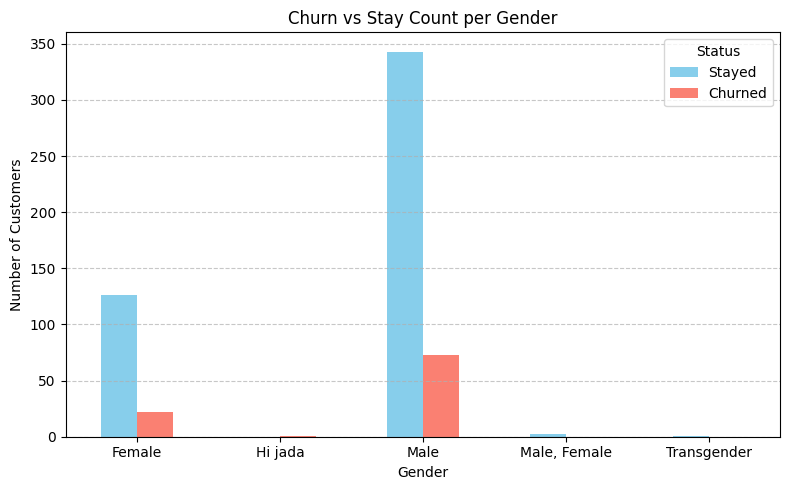

In [62]:
#Bar Chart of Churn Count per Gender
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/Responce file.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Create a Churn column based on satisfaction threshold
# You can change this logic depending on your actual churn labeling
df['Churn'] = (df['satisfication with Services'] < 3).astype(int)

# Group by Gender and Churn status
gender_churn_count = df.groupby('Gender')['Churn'].value_counts().unstack().fillna(0)
gender_churn_count.columns = ['Stayed', 'Churned']
gender_churn_count = gender_churn_count.astype(int)

# Plotting
gender_churn_count.plot(kind='bar', figsize=(8, 5), color=['skyblue', 'salmon'])
plt.title("Churn vs Stay Count per Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Status")
plt.tight_layout()
plt.show()


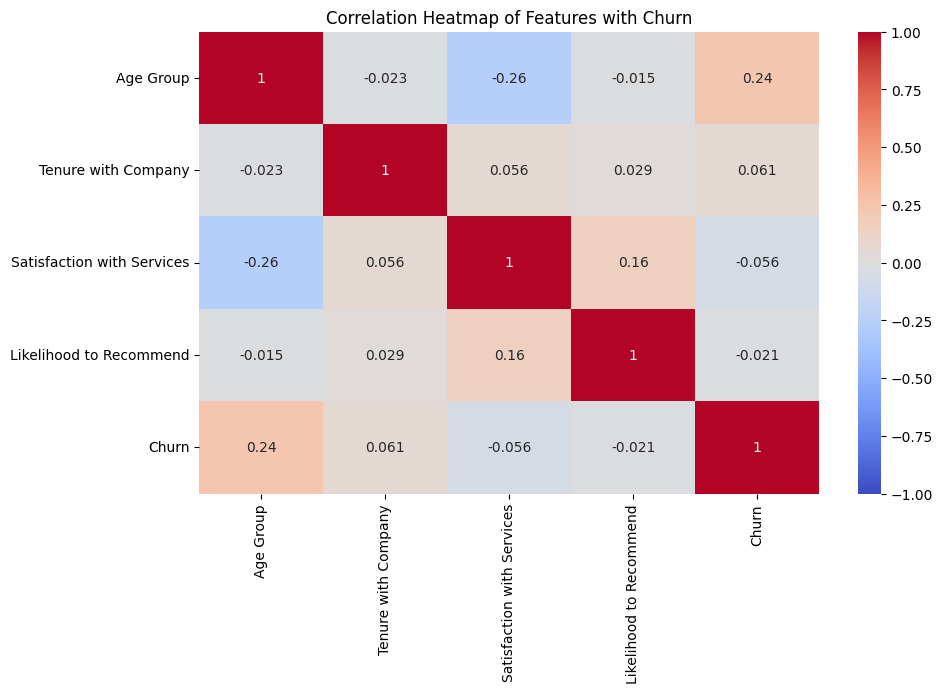

In [22]:
# A. Correlation Matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  # Import pandas

# Sample data frame to mimic relevant features in churn analysis


# Generating a mock dataset (This would ideally be replaced with the user's real dataset)
import numpy as np
np.random.seed(0)
mock_data = pd.DataFrame({
    'Age Group': np.random.randint(1, 5, 100), #low high and size
    'Tenure with Company': np.random.randint(1, 5, 100),
    'Satisfaction with Services': np.random.randint(1, 6, 100),
    'Likelihood to Recommend': np.random.randint(1, 6, 100),
    'Churn': np.random.randint(0, 2, 100)
})

# Calculating correlation matrix
correlation_matrix = mock_data.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Features with Churn")
plt.show()


Text(0, 0.5, 'Frequency')

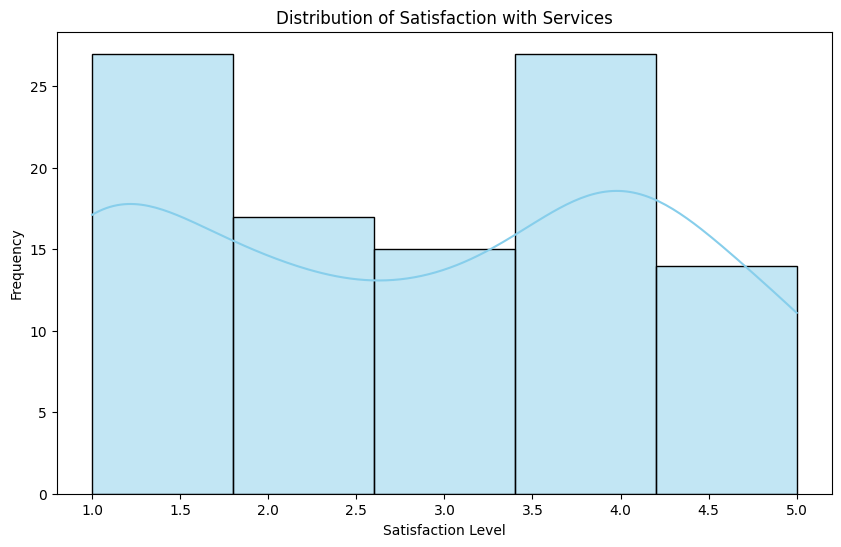

In [23]:
# B. Satisfaction Distribution
plt.figure(figsize=(10, 6))
sns.histplot(mock_data['Satisfaction with Services'], bins=5, kde=True, color='skyblue')
plt.title('Distribution of Satisfaction with Services')
plt.xlabel('Satisfaction Level')
plt.ylabel('Frequency')

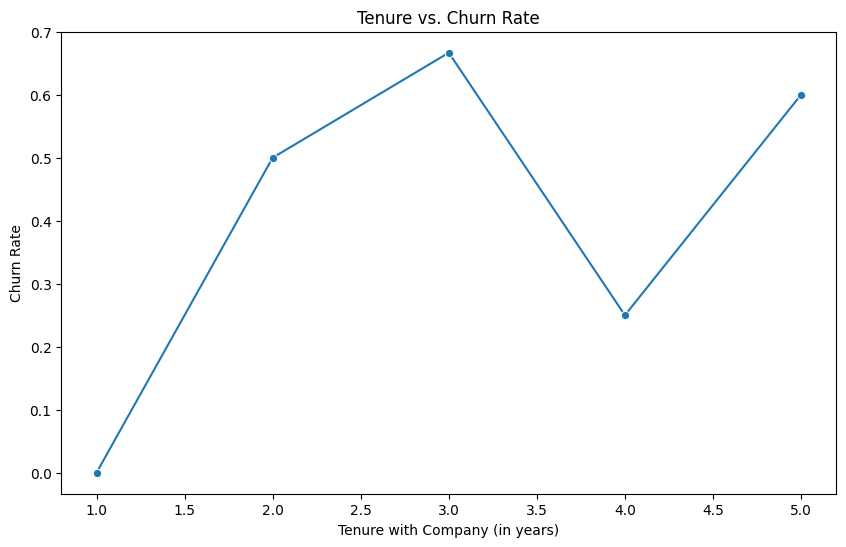

In [25]:
# C. Tenure vs Churn Rate
#Steps to Create a Tenure vs. Churn Rate Plot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data (replace this with your actual dataset)
# Let's assume 'Tenure_with_Company' is in months or years and 'Churn' is binary (0 for retained, 1 for churned)
# Churn: A binary indicator where: 1 means the customer left the service. 0 means the customer stayed
data = pd.DataFrame({
    'Tenure_with_Company': [1, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5],
    'Churn': [0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0]
})

# Calculate churn rate per tenure level
churn_rate = data.groupby('Tenure_with_Company')['Churn'].mean()

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(x=churn_rate.index, y=churn_rate.values, marker='o')
plt.xlabel("Tenure with Company (in years)")
plt.ylabel("Churn Rate")
plt.title("Tenure vs. Churn Rate")
plt.show()



In [26]:
 # step 3 Sentiment Analysis

In [29]:
# #The sentiment analysis of the "Comments and Feedback" column reveals that the feedback provided by customers is largely classified as positive.
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd

# Load your CSV file
file_path = '/content/Responce file.csv'
data = pd.read_csv(file_path)

# Check if data loaded correctly
print("First few rows of data:", data.head())

# Check if 'Comments and Feedback' exists in the columns
print("Columns in dataset:", data.columns)

# Extract 'Comments and Feedback' column, drop missing feedback
if 'Comments and Feedback' in data.columns:
    feedback = data['Comments and Feedback'].dropna()
    print("First few feedback entries:", feedback.head())
else:
    print("'Comments and Feedback' column not found!")

# Download the VADER lexicon for sentiment analysis
nltk.download('vader_lexicon')

# Initialize the VADER sentiment intensity analyzer
sia = SentimentIntensityAnalyzer()

# Function to calculate sentiment using VADER
def vader_sentiment(text):
    sentiment_score = sia.polarity_scores(text)
    return sentiment_score['compound']  # 'compound' gives the overall sentiment score

# Apply sentiment analysis
vader_feedback_sentiment = feedback.apply(vader_sentiment)

# Classify the sentiment based on compound score
def classify_vader_sentiment(compound_score):
    if compound_score > 0:
        return "Positive"
    elif compound_score < 0:
        return "Negative"
    else:
        return "Neutral"

# Apply classification
vader_sentiment_classification = vader_feedback_sentiment.apply(classify_vader_sentiment)

# Combine the original feedback with sentiment classification
vader_feedback_report = pd.DataFrame({
    'Feedback': feedback,
    'Sentiment': vader_sentiment_classification
})

# Display the sentiment analysis report
print("Sentiment analysis results:")
print(vader_feedback_report.head())


First few rows of data:             Timestamp                 Full Name                     Email   \
0  8/23/2024 15:34:21      Omkar Keshav Shitole    omkarkshitole@gmail.com   
1  8/25/2024 17:21:06              omkar Shitole   omkarkshitole@gmail.com   
2  8/25/2024 20:01:42  Savkar Bhagyashree Dinkar      bsavkar123@gmail.com   
3  8/26/2024 20:59:42                Sohel patel  sohelpatel8860@gmail.com   
4  8/26/2024 21:01:50                    Sohel P  sohelpatel4886@gmail.com   

  Mobile Number Age Group  Gender     Location Martial Status Occupation  \
0    8975295673     18-24    Male         Pune            NaN   Student    
1    8975295673     18-24    Male         pune         Single   Student    
2    8177875913     18-24  Female         Pune         Single   Student    
3   07666069428     18-24    Male        Pune          Single   Student    
4   07666069428     18-24    Male  Pimpri,Pune         Single    Student   

  Simcard Company Tenure with Company  Current Ser

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Sentiment analysis results:
                                             Feedback Sentiment
4   Best And Great Experience while Streaming, No ...  Positive
9   Jio is the best company for today's time and i...  Positive
12                                               Good  Positive
14                             I really like the form  Positive
15                     Beautiful method as a teacher   Positive


In [30]:
#The sentiment analysis of the "Comments and Feedback" column reveals that the feedback provided by customers is largely classified as positive.
from textblob import TextBlob

# Extract the 'Comments and Feedback' column and drop any rows with missing feedback
feedback = data['Comments and Feedback'].dropna()

# Function to calculate sentiment polarity
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

# Apply sentiment analysis to each feedback comment
feedback_sentiment = feedback.apply(get_sentiment)

# Classify the sentiment based on polarity score
def classify_sentiment(polarity):
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

# Apply classification to feedback sentiment
sentiment_classification = feedback_sentiment.apply(classify_sentiment)

# Combine original feedback and sentiment classification for a report
feedback_report = pd.DataFrame({
    'Feedback': feedback,
    'Sentiment': sentiment_classification
})

# Show the sentiment analysis report
feedback_report.head()


,Feedback,Sentiment
4,"Best And Great Experience while Streaming, No ...",Positive
9,Jio is the best company for today's time and i...,Positive
12,Good,Positive
14,I really like the form,Positive
15,Beautiful method as a teacher,Positive


/usr/local/lib/python3.11/dist-packages/google/colab/_quickchart_lib.py:32: UserWarning: Glyph 128591 (\N{PERSON WITH FOLDED HANDS}) missing from font(s) DejaVu Sans.
  plt.savefig(


from matplotlib import pyplot as plt
import seaborn as sns
_df_5.groupby('Feedback').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [52]:
# All columns Sentimental analysis
import pandas as pd
from textblob import TextBlob

# Load the dataset
file_path = '/content/Responce file.csv'
data = pd.read_csv(file_path)

# Define a function to calculate sentiment polarity
def get_sentiment(text):
    if pd.isnull(text):  # Handle missing values
        return None
    analysis = TextBlob(str(text))
    return analysis.sentiment.polarity

# Define a function to classify sentiment
def classify_sentiment(polarity):
    if polarity is None:
        return "No Sentiment"
    elif polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

# Columns to analyze
columns_to_analyze = [
    'Tenure with Company',
    'Current Service Used',
    'Preferred  Payment Method',
    'satisfication with Services',
    'Resaons For Choose Current Service',
    'Likelihood to Recommend',
    'Comments and Feedback'
]

# Create a dictionary to store sentiment analysis results for each column
sentiment_analysis_results = {}

for column in columns_to_analyze:
    if column in data.columns:
        # Calculate sentiment polarity
        polarity = data[column].apply(get_sentiment)
        # Classify sentiment
        sentiment_classification = polarity.apply(classify_sentiment)
        # Store results in a dictionary
        sentiment_analysis_results[column] = pd.DataFrame({
            'Original': data[column],
            'Polarity': polarity,
            'Sentiment': sentiment_classification
        })

# Export or inspect sentiment analysis for a specific column
for column, result in sentiment_analysis_results.items():
    print(f"\nSentiment Analysis for Column: {column}")
    print(result.head())

# Optional: Save the sentiment analysis results to CSV files
for column, result in sentiment_analysis_results.items():
    result.to_csv(f"{column}_Sentiment_Analysis.csv", index=False)



Sentiment Analysis for Column: Tenure with Company
            Original  Polarity Sentiment
0  Less than  1 Year -0.166667  Negative
1          1-2 Years  0.000000   Neutral
2          3-5 Years  0.000000   Neutral
3  More Than 5 Years  0.500000  Positive
4  More Than 5 Years  0.500000  Positive

Sentiment Analysis for Column: Current Service Used
               Original  Polarity Sentiment
0              Internet       0.0   Neutral
1                Mobile       0.0   Neutral
2      Mobile, Internet       0.0   Neutral
3  Mobile, Internet, TV       0.0   Neutral
4  Mobile, Internet, TV       0.0   Neutral

Sentiment Analysis for Column: Preferred  Payment Method
         Original  Polarity Sentiment
0  Mobile Payment       0.0   Neutral
1     Credit Card       0.0   Neutral
2  Mobile Payment       0.0   Neutral
3  Mobile Payment       0.0   Neutral
4  Mobile Payment       0.0   Neutral

Sentiment Analysis for Column: satisfication with Services
   Original  Polarity Sentiment
0      

In [34]:
#  step 4 Train-Test Split
# Train-Test Split: Split the dataset into training and testing sets.

In [36]:
# Selecting relevant features for customer churn prediction
features = [
    'Age Group', 'Gender', 'Location', 'Martial Status', 'Occupation',
    'Simcard Company', 'Tenure with Company', 'Current Service Used',
    'satisfication with Services', 'Resaons For Choose Current Service',
    'Likelihood to Recommend', 'Preferred  Payment Method'
]

# Extracting the selected features from the cleaned data
churn_data = data_cleaned[features]

# Display the first few rows of the selected data for review
churn_data.head()


,Age Group,Gender,Location,Martial Status,Occupation,Simcard Company,Tenure with Company,Current Service Used,satisfication with Services,Resaons For Choose Current Service,Likelihood to Recommend,Preferred Payment Method
0,18-24,Male,pune,NaN,Student,Unknown,Less than 1 Year,Internet,4,Service Quality,3,Mobile Payment
1,18-24,Male,pune,Single,Student,Unknown,1-2 Years,Mobile,5,Price,5,Credit Card
2,18-24,Female,pune,Single,Student,Airtel,3-5 Years,"Mobile, Internet",4,Service Quality,3,Mobile Payment
3,18-24,Male,pune,Single,Student,Airtel,More Than 5 Years,"Mobile, Internet, TV",4,Service Quality,5,Mobile Payment
4,18-24,Male,"pimpri,pune",Single,Student,Airtel,More Than 5 Years,"Mobile, Internet, TV",5,Service Quality,5,Mobile Payment


In [37]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# List of columns to encode
categorical_columns = ['Age Group', 'Gender', 'Location', 'Martial Status', 'Occupation',
                       'Simcard Company', 'Current Service Used', 'Preferred  Payment Method']

# Apply Label Encoding to each categorical column using .loc to avoid the warning
for col in categorical_columns:
    churn_data.loc[:, col] = le.fit_transform(churn_data[col])

# Display the first few rows of the encoded data
churn_data.head()

,Age Group,Gender,Location,Martial Status,Occupation,Simcard Company,Tenure with Company,Current Service Used,satisfication with Services,Resaons For Choose Current Service,Likelihood to Recommend,Preferred Payment Method
0,1,2,72,3,127,13,Less than 1 Year,1,4,Service Quality,3,5
1,1,2,72,1,127,13,1-2 Years,6,5,Price,5,3
2,1,0,72,1,127,0,3-5 Years,7,4,Service Quality,3,5
3,1,2,72,1,127,0,More Than 5 Years,9,4,Service Quality,5,5
4,1,2,70,1,126,0,More Than 5 Years,9,5,Service Quality,5,5


from matplotlib import pyplot as plt
_df_6['satisfication with Services'].plot(kind='hist', bins=20, title='satisfication with Services')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_7['Likelihood to Recommend'].plot(kind='hist', bins=20, title='Likelihood to Recommend')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_8.groupby('Gender').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_9.groupby('Location').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_20['Location'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_20, x='satisfication with Services', y='Location', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_21['Martial Status'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_21, x='satisfication with Services', y='Martial Status', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_22['Occupation'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_22, x='satisfication with Services', y='Occupation', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [39]:
print(data_cleaned.columns)


Index(['Timestamp', 'Full Name ', 'Email ', 'Mobile Number', 'Age Group',
       'Gender', 'Location', 'Martial Status', 'Occupation', 'Simcard Company',
       'Tenure with Company', 'Current Service Used',
       'Preferred  Payment Method', 'satisfication with Services',
       'Resaons For Choose Current Service', 'Likelihood to Recommend',
       'Comments and Feedback', 'Consent  to Participate'],
      dtype='object')


In [41]:
from sklearn.model_selection import train_test_split # Import train_test_split

# Assuming 'churn_data' contains your features and 'Simcard Company' is your target variable
X = churn_data.drop(columns=['Simcard Company'])  # Features (exclude the target variable)
y = churn_data['Simcard Company']  # Target variable

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the resulting datasets
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

Training features shape: (454, 11)
Testing features shape: (114, 11)
Training labels shape: (454,)
Testing labels shape: (114,)


In [42]:
# step 5 ANN and LSTM
# A. ACCURACY ANN test ACCURACY
# B.  LSTM test Accuracy
# C. Model comparison

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4479 - loss: 7.7047 - val_accuracy: 0.4505 - val_loss: 4.4258
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4191 - loss: 3.9930 - val_accuracy: 0.5714 - val_loss: 2.2928
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5443 - loss: 2.4140 - val_accuracy: 0.5714 - val_loss: 1.8160
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5947 - loss: 1.7506 - val_accuracy: 0.5385 - val_loss: 1.3944
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5271 - loss: 1.3553 - val_accuracy: 0.5714 - val_loss: 1.0472
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6312 - loss: 0.8888 - val_accuracy: 0.5824 - val_loss: 0.9231
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6520 - loss: 0.7799 - val_accuracy: 0.5495 - val_loss: 0.8910
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6849 - loss: 0.7885 - val_accuracy: 0.5934 - val_loss

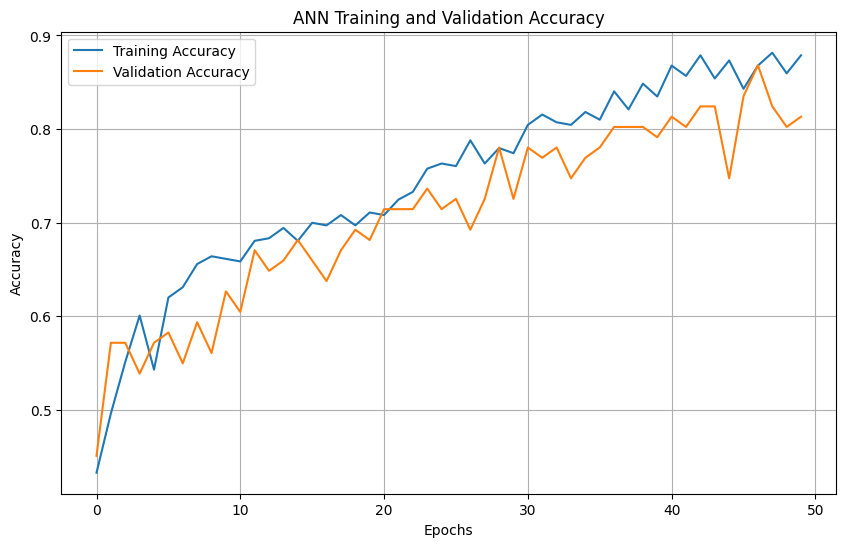

In [43]:
# Import necessary libraries
# ANN Model test Accurrecy
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Load the dataset
file_path = "/content/Responce file.csv"
data = pd.read_csv(file_path)

# Preprocessing: Clean the dataset
data.columns = data.columns.str.strip()  # Remove leading/trailing spaces
data_cleaned = data.drop(columns=["Timestamp", "Full Name", "Email", "Mobile Number",
                                   "Comments and Feedback", "Consent  to Participate"], errors='ignore')

# Rename columns for consistency


# Define churn based on Satisfaction and Recommend Likelihood
data_cleaned["Churn"] = ((data_cleaned["satisfication with Services"].astype(float) <= 3) |
                         (data_cleaned["Likelihood to Recommend"].astype(float) <= 3)).astype(int)

# Encode categorical variables
categorical_cols = ["Age Group", "Gender", "Location", "Martial Status", "Occupation",
                    "Simcard Company", "Tenure with Company", "Current Service Used", "Preferred  Payment Method",
                    "Resaons For Choose Current Service"]

label_encoders = {col: LabelEncoder() for col in categorical_cols}
for col in categorical_cols:
    data_cleaned[col] = label_encoders[col].fit_transform(data_cleaned[col])

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ["satisfication with Services", "Likelihood to Recommend"]
data_cleaned[numerical_cols] = scaler.fit_transform(data_cleaned[numerical_cols])

# Split data into features (X) and target (y)
X = data_cleaned.drop(columns=["Churn"])
y = data_cleaned["Churn"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the ANN model
model = Sequential([
    Dense(16, activation='relu', input_dim=X_train.shape[1]),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Plot the training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5033 - loss: 1.6386 - val_accuracy: 0.4835 - val_loss: 0.8681
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5752 - loss: 1.0485 - val_accuracy: 0.5604 - val_loss: 0.7434
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5838 - loss: 0.9872 - val_accuracy: 0.5934 - val_loss: 0.6864
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5386 - loss: 0.9829 - val_accuracy: 0.5495 - val_loss: 0.6945
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5252 - loss: 0.9184 - val_accuracy: 0.5495 - val_loss: 0.6891
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5363 - loss: 0.8888 - val_accuracy: 0.5495 - val_loss: 0.6769
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5346 - loss: 0.8930 - val_accuracy: 0.5934 - val_loss: 0.6673
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4777 - loss: 0.8559 - val_accuracy: 0.5714 - val_loss: 0.6597
Ep

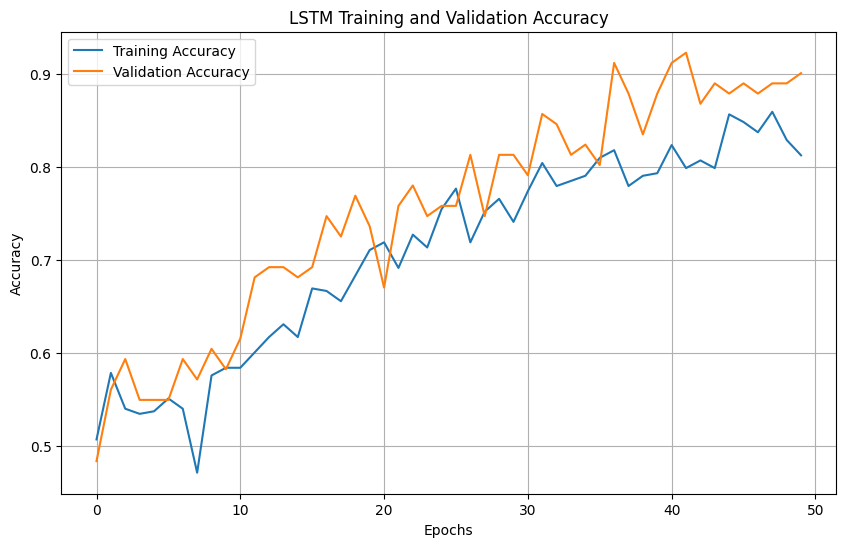

<Figure size 640x480 with 0 Axes>

In [45]:
# LSTM test Accuracy
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import matplotlib.pyplot as plt

# Load the dataset
file_path = "/content/Responce file.csv"
data = pd.read_csv(file_path)

# Preprocessing: Clean the dataset
data.columns = data.columns.str.strip()  # Remove leading/trailing spaces
data_cleaned = data.drop(columns=["Timestamp", "Full Name", "Email", "Mobile Number",
                                   "Comments and Feedback", "Consent  to Participate"], errors='ignore')

# Define churn based on Satisfaction and Recommend Likelihood
data_cleaned["Churn"] = ((data_cleaned["satisfication with Services"].astype(float) <= 3) |
                         (data_cleaned["Likelihood to Recommend"].astype(float) <= 3)).astype(int)

# Encode categorical variables
categorical_cols = ["Age Group", "Gender", "Location", "Martial Status", "Occupation",
                    "Simcard Company", "Tenure with Company", "Current Service Used", "Preferred  Payment Method",
                    "Resaons For Choose Current Service"]

label_encoders = {col: LabelEncoder() for col in categorical_cols}
for col in categorical_cols:
    data_cleaned[col] = label_encoders[col].fit_transform(data_cleaned[col])

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ["satisfication with Services", "Likelihood to Recommend"]
data_cleaned[numerical_cols] = scaler.fit_transform(data_cleaned[numerical_cols])

# Split data into features (X) and target (y)
X = data_cleaned.drop(columns=["Churn"])
y = data_cleaned["Churn"]

# Reshape data for LSTM: (samples, timesteps, features)
X = np.expand_dims(X.values, axis=1)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the LSTM model
model = Sequential([
    LSTM(32, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"LSTM Test Accuracy: {test_accuracy * 100:.2f}%")

# Plot the training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Save the plot
plt.savefig("lstm_training_accuracy.png")


In [54]:
# Model Comparison ANN and LSTM

In [55]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.utils import to_categorical

# Load dataset (replace 'data.csv' with your actual dataset)
file_path = '/content/Responce file.csv'
data = pd.read_csv(file_path)

# Inspect dataset to find the target column
print("Columns in dataset:", data.columns)


# Preprocess dataset
# Encode categorical variables and handle missing values
data = data.dropna()
label_encoder = LabelEncoder()
data['satisfication with Services'] = label_encoder.fit_transform(data['satisfication with Services'])  # Target column

# Select features and target
X = data.drop(columns=['satisfication with Services'])
y = data['satisfication with Services']

# Encode categorical columns
for column in X.select_dtypes(include=['object']).columns:
    X[column] = label_encoder.fit_transform(X[column])

# Standardize numerical features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ANN Model
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train ANN model
ann_history = ann_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Evaluate ANN model
ann_accuracy = ann_model.evaluate(X_test, y_test, verbose=0)[1]
print(f"ANN Accuracy: {ann_accuracy * 100:.2f}%")

# Reshape data for LSTM model (3D input: samples, timesteps, features)
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# LSTM Model
lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(1, X_train.shape[1]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train LSTM model
lstm_history = lstm_model.fit(X_train_lstm, y_train, epochs=50, batch_size=32, validation_data=(X_test_lstm, y_test), verbose=1)

# Evaluate LSTM model
lstm_accuracy = lstm_model.evaluate(X_test_lstm, y_test, verbose=0)[1]
print(f"LSTM Accuracy: {lstm_accuracy * 100:.2f}%")

# Compare results
print("\nModel Comparison:")
print(f"ANN Accuracy: {ann_accuracy * 100:.2f}%")
print(f"LSTM Accuracy: {lstm_accuracy * 100:.2f}%")


Columns in dataset: Index(['Timestamp', 'Full Name ', 'Email ', 'Mobile Number', 'Age Group',
       'Gender', 'Location', 'Martial Status', 'Occupation', 'Simcard Company',
       'Tenure with Company', 'Current Service Used',
       'Preferred  Payment Method', 'satisfication with Services',
       'Resaons For Choose Current Service', 'Likelihood to Recommend',
       'Comments and Feedback', 'Consent  to Participate'],
      dtype='object')
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.1477 - loss: 0.5619 - val_accuracy: 0.0800 - val_loss: 0.2014
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1185 - loss: 0.4242 - val_accuracy: 0.0800 - val_loss: -0.1880
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1136 - loss: -0.1047 - val_accuracy: 0.0800 - val_loss: -0.5710
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1365 - loss: -0.5364 - val_accuracy: 0.0800 - val_loss: -0.9454
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1115 - loss: -0.8784 - val_accuracy: 0.0800 - val_loss: -1.3273
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1199 - loss: -1.3574 - val_accuracy: 0.0800 - val_loss: -1.7254
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0990 - loss: -1.7987 - val_accuracy: 0.0800 - val_loss: -2.1457
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1480 - loss: -1.8426 - val_accuracy: 0.0800 - val_loss: -2.57

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 256ms/step - accuracy: 0.1350 - loss: 0.6843 - val_accuracy: 0.1200 - val_loss: 0.6688
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.1598 - loss: 0.6438 - val_accuracy: 0.1600 - val_loss: 0.6399
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1442 - loss: 0.6105 - val_accuracy: 0.1600 - val_loss: 0.6126
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1659 - loss: 0.5803 - val_accuracy: 0.1200 - val_loss: 0.5824
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1887 - loss: 0.5518 - val_accuracy: 0.1200 - val_loss: 0.5491
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1475 - loss: 0.5030 - val_accuracy: 0.1200 - val_loss: 0.5120
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1605 - loss: 0.4759 - val_accuracy: 0.1200 - val_loss: 0.4707
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1755 - loss: 0.4176 - val_accuracy: 0.1200 - val_loss: 0.4274
Epoch 9/50

In [46]:
# step 6 . Evaluation Metrics
# 1. Bar Chart of Precision, Recall, F1
# 2. Confusion Matrix

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predictions
y_pred = model.predict(X_test) > 0.5

# Metrics
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        49
           1       0.86      0.92      0.89        65

    accuracy                           0.87       114
   macro avg       0.87      0.86      0.86       114
weighted avg       0.87      0.87      0.87       114

Accuracy: 0.868421052631579


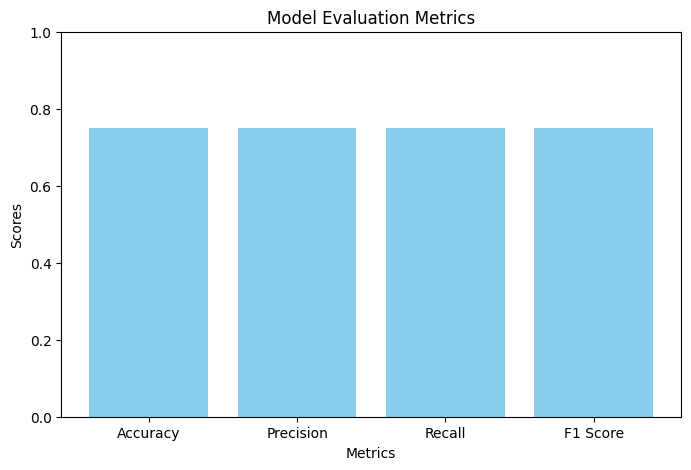

In [48]:
#model evalution
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Example true labels and predicted labels
y_true = [0, 1, 0, 1, 1, 0, 1, 0]  # True labels
y_pred = [0, 0, 0, 1, 1, 0, 1, 1]  # Predicted labels

# Calculating evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Plotting a bar chart for model performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, scores, color='skyblue')
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Model Evaluation Metrics')
plt.ylim(0, 1)  # Set y-axis limit to 0-1 for better visualization
plt.show()


In [51]:
# precision    recall  f1-score   support
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Load the dataset
file_path = r'/content/Responce file.csv'
data = pd.read_csv(file_path)

# Feature selection: Selecting relevant features for churn prediction
selected_columns = ['Age Group', 'Gender', 'Location', 'Occupation', 'Simcard Company',
                    'Tenure with Company', 'Current Service Used', 'Preferred  Payment Method',
                    'satisfication with Services', 'Likelihood to Recommend']

X = data[selected_columns].copy()  # Use .copy() to avoid SettingWithCopyWarning

# Assuming 'Churn' or a similar column is your target variable (replace this with the correct churn column if needed)
y = data['Likelihood to Recommend']  # Replace with actual churn column

# Encode categorical variables to numeric format
label_encoders = {}
for column in X.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    X.loc[:, column] = label_encoders[column].fit_transform(X[column])  # Use .loc[] for proper assignment

# Encode the target variable (if needed)
y = LabelEncoder().fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Instantiate the Multinomial Naive Bayes classifier
model = MultinomialNB()

# Train the model
model.fit(X_train, y_train)

# Predict on the test data
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.47      0.64        17
           1       0.22      0.40      0.29        15
           2       0.33      0.42      0.37        45
           3       0.42      0.19      0.26        68
           4       0.21      0.38      0.27        26

    accuracy                           0.33       171
   macro avg       0.44      0.37      0.37       171
weighted avg       0.40      0.33      0.33       171



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


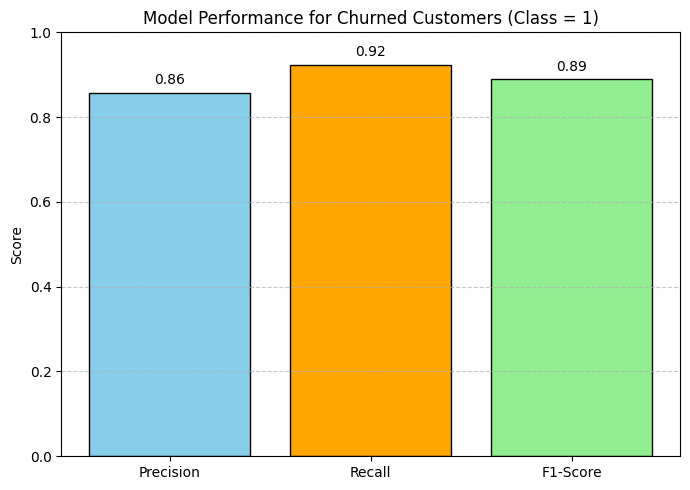

In [50]:
# Bar Chart of Precision, Recall, F1
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Step 1: Get predictions from your model
# Assuming you already trained a model and have test data (X_test, y_test)
# For binary classification (0/1), threshold predictions at 0.5
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Step 2: Generate classification report as dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Step 3: Extract metrics for class '1' (churned customers)
precision = report['1']['precision']
recall = report['1']['recall']
f1_score = report['1']['f1-score']

# Step 4: Plot the bar chart
metrics = ['Precision', 'Recall', 'F1-Score']
values = [precision, recall, f1_score]

plt.figure(figsize=(7, 5))
bars = plt.bar(metrics, values, color=['skyblue', 'orange', 'lightgreen'], edgecolor='black')
plt.title('Model Performance for Churned Customers (Class = 1)')
plt.ylim(0, 1)
plt.ylabel('Score')

# Annotate bars with values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.2f}', ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



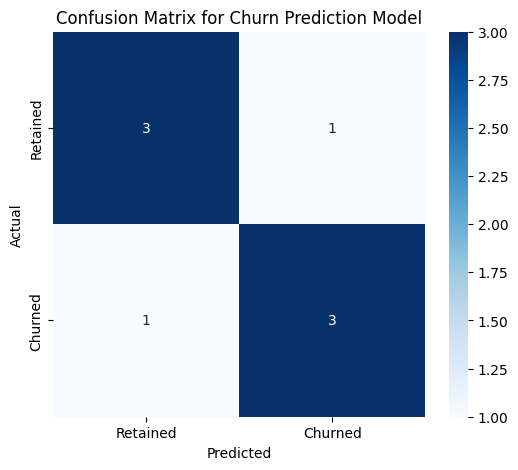

In [53]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Example true labels and predicted labels (replace these with your actual data)
y_true = [0, 1, 0, 1, 1, 0, 1, 0]  # True labels
y_pred = [0, 0, 0, 1, 1, 0, 1, 1]  # Predicted labels

# Calculating the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting the confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Churn Prediction Model')
plt.show()



In [56]:
# Step 7 . Final User Interaction: Will the Customer Churn?

In [57]:
import pandas as pd

def load_data(file_path):
    """Load customer response data from CSV and clean column names."""
    file_path = "/content/Responce file.csv"
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()  # Remove extra spaces from column names
    return df

def predict_churn(name, df):
    """Predict whether a customer will leave or continue service."""
    name_column = 'Full Name'
    if name_column not in df.columns:
        return "Error: 'Full Name' column not found in the dataset."

    customer = df[df[name_column].str.lower() == name.lower()]

    if customer.empty:
        return "Customer not found. Please enter a valid name."

    satisfaction = customer['satisfication with Services'].values[0]
    recommend = customer['Likelihood to Recommend'].values[0]

    if satisfaction < 3 and recommend < 3:
        return f"{name} is likely to leave the service."
    else:
        return f"{name} will continue using the service."

if __name__ == "__main__":
    file_path = "Responce file.csv"  # Ensure this file is in the same directory
    df = load_data(file_path)

    while True:
        name = input("Enter customer name (or type 'exit' to quit): ")
        if name.lower() == 'exit':
            break
        print(predict_churn(name, df))


Enter customer name (or type 'exit' to quit): Omkar Keshav Shitole 
Omkar Keshav Shitole  will continue using the service.


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-57-e8890322d693>", line 34, in <cell line: 0>
    name = input("Enter customer name (or type 'exit' to quit): ")
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 1177, in raw_input
    return self._input_request(
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 1219, in _input_request
    raise KeyboardInterrupt("Interrupted by user") from None
KeyboardInterrupt: Interrupted by user

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback
    stb = value._rend

TypeError: object of type 'NoneType' has no len()